In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output


<Axes: >

2024-04-24 18:00:00


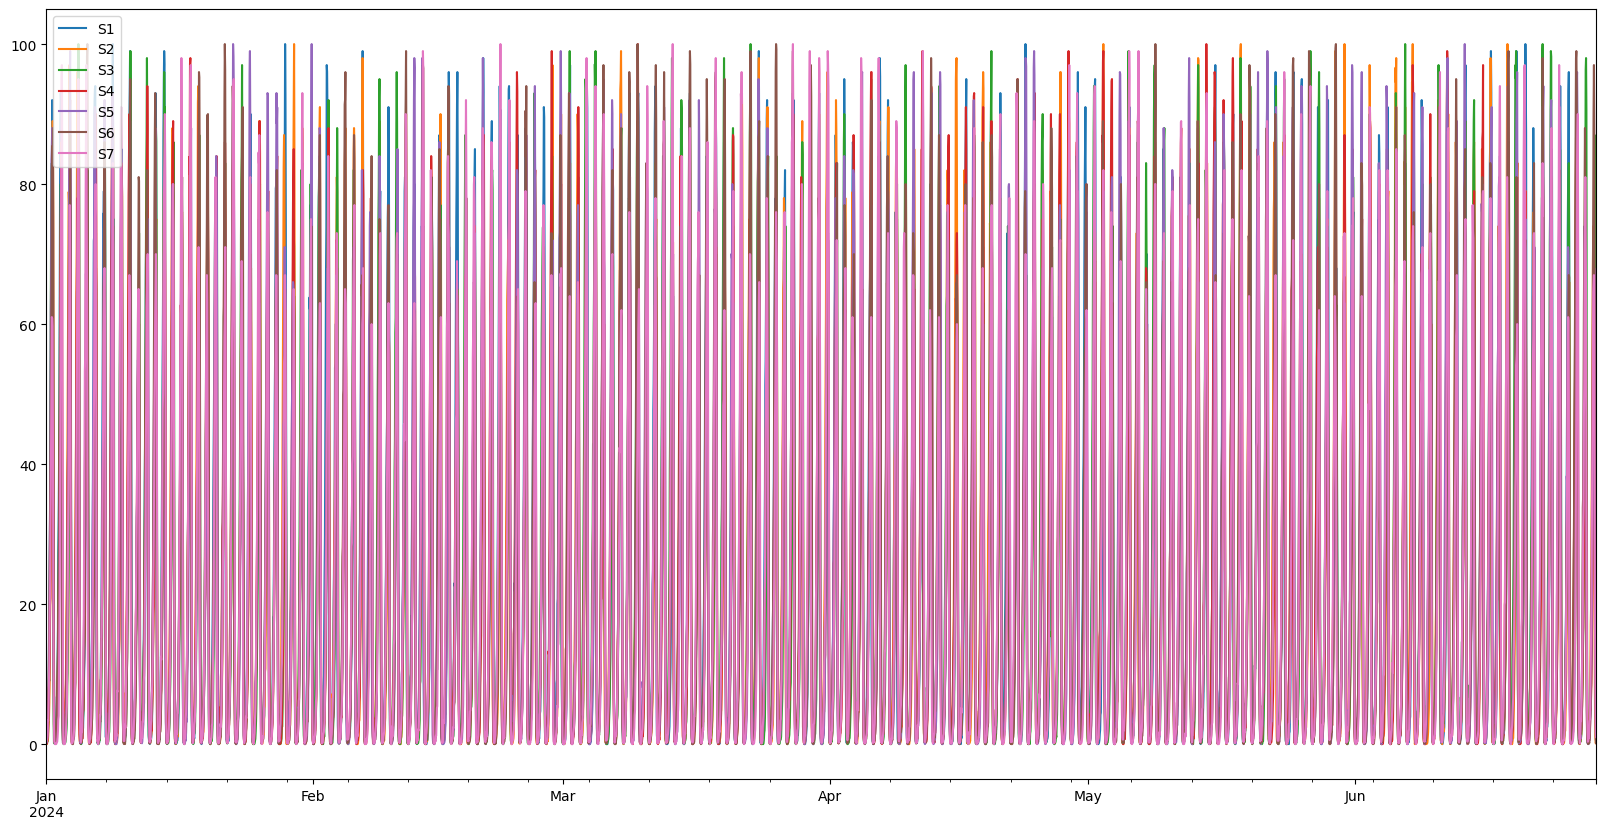

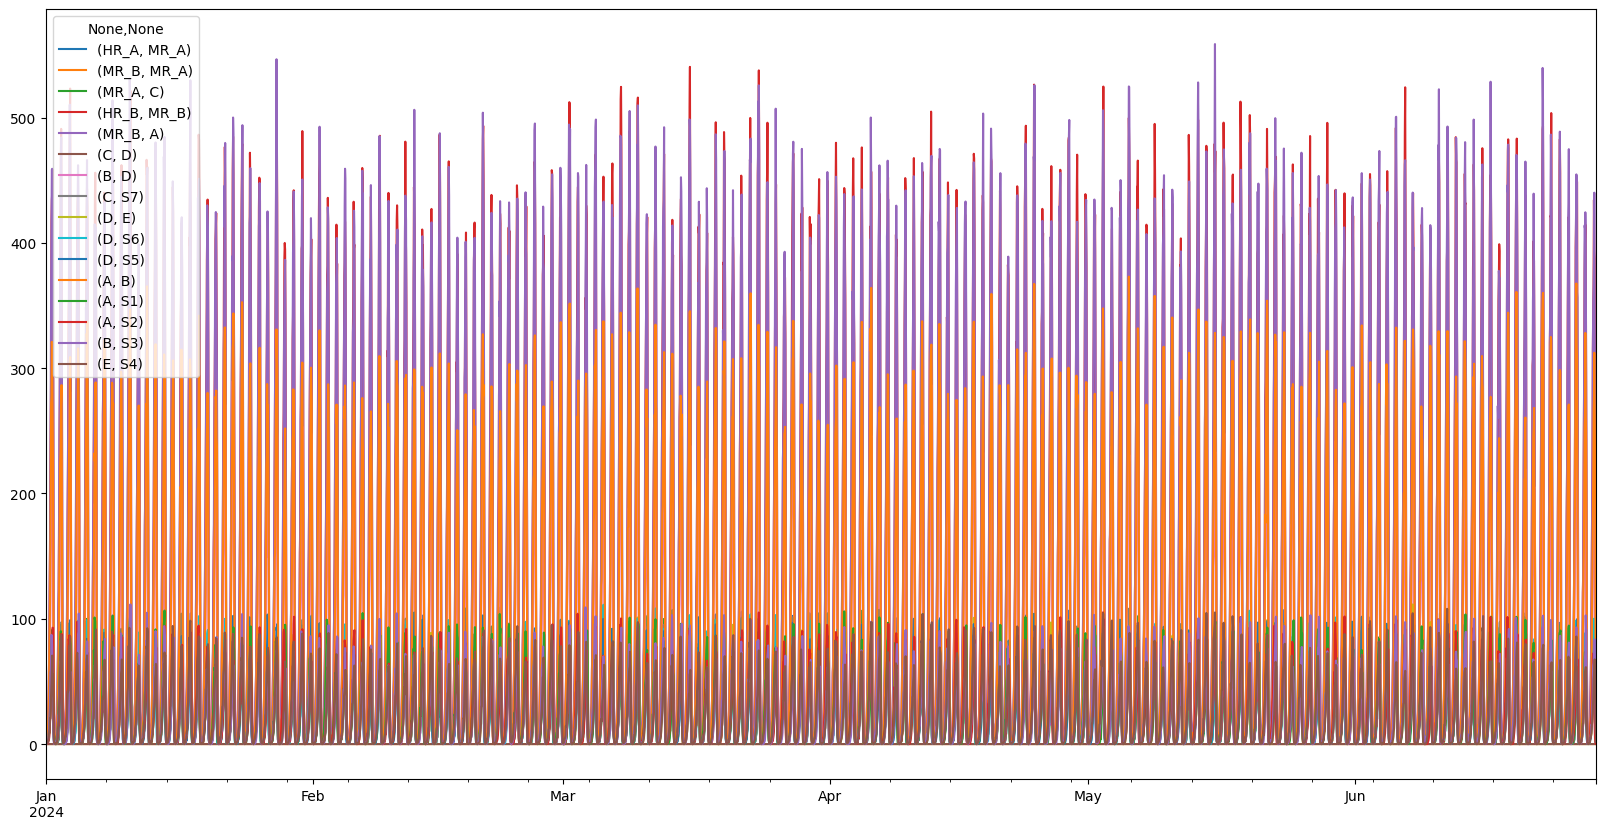

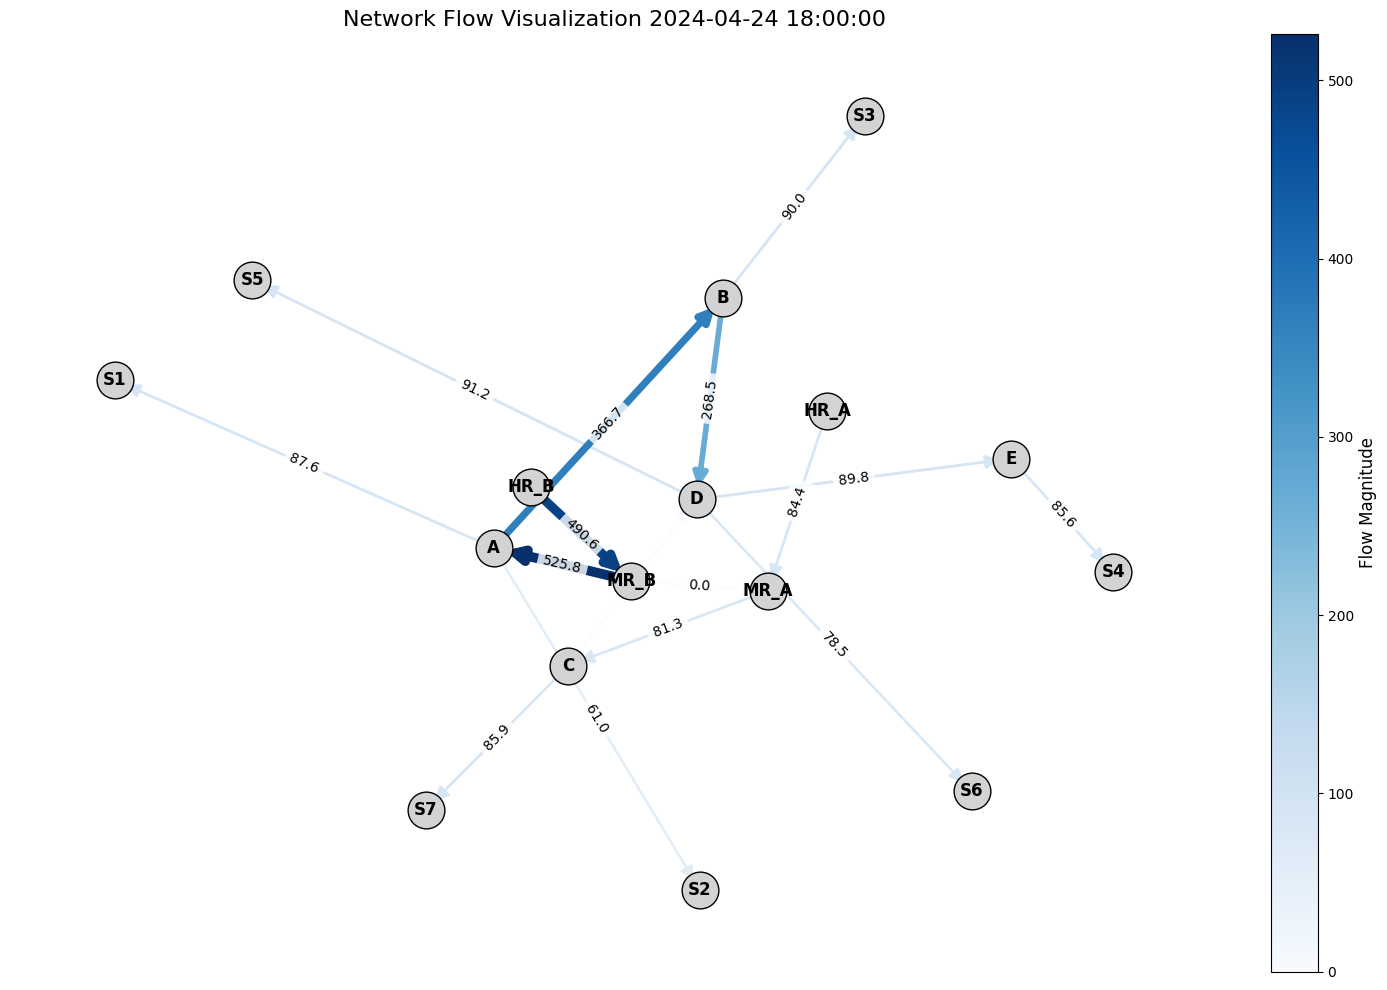

In [2]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

def visualize_flow_series(G, flow_series, title="Network Flow Visualization"):
    """
    Visualizes a networkx Graph with flow values from a pandas Series.
    
    Parameters:
    - G: networkx.Graph or DiGraph
    - flow_series: pd.Series where index is edges (u,v) and values are floats.
    """
    
    # 1. Setup Figure
    plt.figure(figsize=(14, 10), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # 2. Generate "Spread" Layout
    # We scale 'k' (repulsive force) based on node count to keep it sparse
    k_val = 2.0 / np.sqrt(len(G.nodes())) if len(G.nodes()) > 0 else 1
    pos = nx.spring_layout(G, k=k_val, iterations=50, seed=42)

    # 3. Process Edge Styles
    edge_colors = []
    edge_widths = []
    edge_labels = {}
    
    # Handle empty series or all zeros
    if flow_series.empty:
        max_val = 1.0
    else:
        max_val = flow_series.max()
        if max_val == 0: max_val = 1.0

    for u, v in G.edges():
        # Retrieve flow safely, checking both (u,v) and (v,u)
        val = 0.0
        if (u, v) in flow_series.index:
            val = flow_series.loc[(u, v)]
        elif (v, u) in flow_series.index:
            val = flow_series.loc[(v, u)]
        
        # Color: Map value directly
        edge_colors.append(val)
        
        # Width: Base width (1.0) + scaled extra width (up to 6.0)
        width_scale = 1.0 + (val / max_val) * 6.0
        edge_widths.append(width_scale)
        
        # Label: formatted string
        edge_labels[(u, v)] = f"{val:.1f}"

    # 4. Draw Components
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightgrey', edgecolors='black')
    
    # Draw Node Labels
    nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold')

    # Draw Edges
    # We use a colormap (Blues) to visualize intensity
    cmap = plt.cm.Blues
    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           edge_color=edge_colors, 
                           edge_cmap=cmap, 
                           edge_vmin=0, 
                           edge_vmax=max_val,
                           arrows=True, arrowstyle='-|>', arrowsize=20)
    
    # Draw Flow Values (with white background for readability)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_color='black', font_size=10,
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

    # 5. Add Colorbar (Robust Method)
    # Create a 'ScalarMappable' explicitly to avoid AttributeError
    norm = mcolors.Normalize(vmin=0, vmax=max_val)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Flow Magnitude', color='black', size=12)
    cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')

    # 6. Final Polish
    plt.title(title, fontsize=16, color='black')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_specific_flow(flow_dict):
    # 2. Reconstruct the Graph from the keys
    G = nx.DiGraph()
    G.add_edges_from(flow_dict.keys())
    
    # 3. Auto-detect Sources and Sinks
    # Sources = Nodes with In-Degree 0
    sources = [n for n in G.nodes if G.in_degree(n) == 0]
    # Sinks = Nodes with Out-Degree 0
    sinks = [n for n in G.nodes if G.out_degree(n) == 0]
    
    print(f"Detected Sources (Inputs): {sources}")
    print(f"Detected Sinks (Outputs): {sinks}")
    
    results = []
    
    # 4. Calculate Balance for Internal Nodes
    for node in G.nodes:
        if node in sources or node in sinks:
            continue
            
        flow_in = 0.0
        flow_out = 0.0
        
        # Sum Inputs
        for u in G.predecessors(node):
            flow_in += flow_dict.get((u, node), 0.0)
            
        # Sum Outputs
        for v in G.successors(node):
            flow_out += flow_dict.get((node, v), 0.0)
            
        balance = flow_in - flow_out
        
        # Determine status
        if abs(balance) < 1e-4:
            status = "✅ Balanced"
        elif balance > 0:
            status = "⚠️ Accumulation (In > Out)"
        else:
            status = "🔻 Leak/Gain (Out > In)" # Out is higher, so flow appeared
            
        results.append({
            "Node": node,
            "Flow In": round(flow_in, 3),
            "Flow Out": round(flow_out, 3),
            "Diff": round(balance, 3),
            "Status": status
        })
        
    #return pd.DataFrame(results).set_index("Node")
    return pd.DataFrame(results).set_index("Node").Diff.mean()


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)
display(DEMANDS.plot(figsize=(20,10)))


RAW_DATA = pd.DataFrame()
for k,v in DEMANDS.iterrows():
    _flow = calculate_edge_flows(G, v.to_dict() )
    _flow.columns = [k]   
    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)

clear_output()

# SIULATING NOISE
NOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)

display(RAW_DATA.T.plot(figsize=(20,10)))

timestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]
print(timestamp)

visualize_flow_series(
    G, 
    RAW_DATA.loc[:,timestamp], 
    title="Network Flow Visualization {}".format(timestamp)
)

In [3]:
#balanced_analysis =RAW_DATA.apply( lambda x: analyze_specific_flow(x.to_dict()) )
#balanced_analysis.plot()

## PREPARATION OF DATA

In [4]:
SAMPLING = '1h'
TSS = RAW_DATA.T.copy()

ORIG_COLUMNS = {f"chn_{i}":TSS.columns[i] for i in range(len(TSS.columns))}
display(ORIG_COLUMNS)
TSS.columns = [f"chn_{i}" for i in range(len(ORIG_COLUMNS))]

TSS = TSS.resample(SAMPLING).mean()
TSS

{'chn_0': ('HR_A', 'MR_A'),
 'chn_1': ('MR_B', 'MR_A'),
 'chn_2': ('MR_A', 'C'),
 'chn_3': ('HR_B', 'MR_B'),
 'chn_4': ('MR_B', 'A'),
 'chn_5': ('C', 'D'),
 'chn_6': ('B', 'D'),
 'chn_7': ('C', 'S7'),
 'chn_8': ('D', 'E'),
 'chn_9': ('D', 'S6'),
 'chn_10': ('D', 'S5'),
 'chn_11': ('A', 'B'),
 'chn_12': ('A', 'S1'),
 'chn_13': ('A', 'S2'),
 'chn_14': ('B', 'S3'),
 'chn_15': ('E', 'S4')}

,chn_0,chn_1,chn_2,chn_3,chn_4,chn_5,chn_6,chn_7,chn_8,chn_9,chn_10,chn_11,chn_12,chn_13,chn_14,chn_15
2024-01-01 00:00:00,0.202826,0.0,0.188137,1.278230,1.099756,0.0,0.815161,0.213689,0.281896,0.152563,0.306273,0.788288,0.256424,0.118821,0.126935,0.305452
2024-01-01 01:00:00,0.291361,0.0,0.304922,0.821613,0.836602,0.0,0.575598,0.295466,0.000000,0.456799,0.141820,0.677885,0.000000,0.128982,0.111851,0.000000
2024-01-01 02:00:00,0.400011,0.0,0.406274,1.932338,1.816459,0.0,1.587177,0.338225,0.293331,0.561241,0.608829,1.652746,0.134823,0.000000,0.270247,0.282883
2024-01-01 03:00:00,0.701030,0.0,0.710819,4.849544,4.482321,0.0,4.257997,0.741661,0.388575,2.250601,0.835873,4.605000,0.261977,0.118882,0.400814,0.436791
2024-01-01 04:00:00,1.281108,0.0,1.247493,8.378168,7.386896,0.0,5.332844,1.252056,1.207454,2.941306,1.709804,6.278770,0.427937,0.750377,1.203328,1.165687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,33.554393,0.0,36.421855,387.491149,335.749797,0.0,199.646447,34.630663,69.324362,54.892776,65.662809,279.371086,76.919397,14.470662,83.606507,67.561931
2024-06-28 20:00:00,16.703460,0.0,16.750497,260.230914,265.173592,0.0,151.854160,17.597648,59.386636,27.286089,53.379578,229.203913,48.562340,5.079284,73.601827,60.482107
2024-06-28 21:00:00,8.572474,0.0,8.742817,142.629640,135.447775,0.0,78.310724,8.238252,39.110801,5.144000,32.459056,120.917141,19.540944,1.227369,46.088056,37.786650
2024-06-28 22:00:00,1.605145,0.0,1.499091,43.537566,45.751627,0.0,24.852353,1.668185,16.105593,0.687616,8.635070,38.063788,5.105376,0.104088,15.402574,14.884691


# PATCHTST

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [7]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

FREQ_H = int((TSS.index[1] - TSS.index[0]).total_seconds() / 3600)


# PREDICTION FOR A DAY
SEQ_LEN = int(3*24*(24/FREQ_H))         # 3 days
PRED_LEN = int(1*24*(24/FREQ_H))          # 1 day

CHANNELS =  TSS.shape[1]
PATCH_LEN = 16
STRIDE = int(PATCH_LEN/2)
PATCH_NUM  = (SEQ_LEN - PRED_LEN) // STRIDE + 1 + 1

TIME_FEATURES = 4   #WEEK, DAY of WEEK, HOUR, MINUTE
D_MODEL = 64

print(f"FREQ_H: {FREQ_H}")
print(f"SEQ_LEN: {SEQ_LEN}")
print(f"PRED_LEN: {PRED_LEN}")
print(f"PATCH_NUM: {PATCH_NUM}")
print(f"CHANNELS: {CHANNELS}")
print(f"PATCH_LEN: {PATCH_LEN}")
print(f"STRIDE: {STRIDE}")
print(f"TIME_FEATURES: {TIME_FEATURES}")
print(f"D_MODEL: {D_MODEL}")


FREQ_H: 1
SEQ_LEN: 1728
PRED_LEN: 576
PATCH_NUM: 146
CHANNELS: 16
PATCH_LEN: 16
STRIDE: 8
TIME_FEATURES: 4
D_MODEL: 64


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [9]:
class TimeSeriesDataset(Dataset):
    """
    Converts a Pandas DataFrame into sliding windows for training.
    Extracts time features (Hour, DayofWeek, Day, Month) from the index.
    """
    def __init__(self, dataframe: pd.DataFrame, seq_len: int, pred_len: int):
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)

        # Ensure index is datetime
        if not isinstance(dataframe.index, pd.DatetimeIndex):
            dataframe.index = pd.to_datetime(dataframe.index)

        # 1. Extract Data Values (Normalized typically happening outside or via RevIN inside model)
        self.data = dataframe.values.astype(np.float32)

        # 2. Extract Time Features from Index
        # We normalize these to 0-based indices for Embedding layers
        df_stamp = dataframe.index
        self.time_features = np.stack([
            df_stamp.hour.values,
            df_stamp.dayofweek.values,     # 0-6
            df_stamp.day.values,
            df_stamp.month.values,
        ], axis=1).astype(np.int32)

    def __len__(self):
        return int( (len(self.data) - self.seq_len - self.pred_len + 1) )

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        # Input Sequence
        seq_x = self.data[s_begin:s_end]
        # Input Time Features
        seq_x_mark = self.time_features[s_begin:s_end]

        # Target Sequence
        seq_y = self.data[r_begin:r_end]

        return torch.tensor(seq_x), torch.tensor(seq_x_mark), torch.tensor(seq_y)


DATA_DS = TimeSeriesDataset(TSS, seq_len=SEQ_LEN, pred_len=PRED_LEN)
DATA_DL = DataLoader(DATA_DS, batch_size=BATCH_SIZE, shuffle=True)


print(f"Total samples: {len(DATA_DS)}")

ts_data, time_data, y = DATA_DS[0]

print(f"Time Serie Shape: {ts_data.shape}")
print(f"Time Features Shape: {time_data.shape}")
print(f"Target Shape: {y.shape}")

Total samples: 2017
Time Serie Shape: torch.Size([1728, 16])
Time Features Shape: torch.Size([1728, 4])
Target Shape: torch.Size([576, 16])


In [10]:
class RevIN(nn.Module):
    """Reversible Instance Normalization to handle distribution shift."""
    def __init__(self, num_features: int, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

        #self.register_buffer('mean', self.mean)
        #self.register_buffer('stdev', self.stdev)

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = (x - self.affine_bias) / (self.affine_weight + self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x

class PatchingLayer(nn.Module):
    """
    Segments the time series into subseries-level patches.
    Input: (Batch, Seq_Len, Channels) or (Batch * Channels, Seq_Len, 1)
    Output: (Batch * Channels, Num_Patches, Patch_Len)
    """
    def __init__(self, patch_len: int, stride: int):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride

    def forward(self, x):
        # x shape: [Batch, Seq_Len, 1] (After Channel Independence Reshape)
        # padding logic to ensure we cover the whole sequence

        padding_needed = self.stride - (x.shape[1] - self.patch_len) % self.stride
        
        if padding_needed == self.stride:
            padding_needed = 0

        # Pad the LAST value of the sequence
        if padding_needed > 0:
            last_val = x[:, -1:, :]
            x_pad = torch.cat([x, last_val.repeat(1, padding_needed, 1)], dim=1)
        else:
            x_pad = x

        # Unfold: Create patches
        # [Batch, Seq_Len, 1] -> [Batch, Num_Patches, Patch_Len]
        # We use unfold on dimension 1
        patches = x_pad.unfold(dimension=1, size=self.patch_len, step=self.stride)

        # Current shape: [Batch, Num_Patches, 1, Patch_Len]
        # We squeeze the channel dim (which is 1 due to Channel Independence)
        patches = patches.squeeze(2)

        return patches

class TemporalEmbedding(nn.Module):
    """
    Embeds Hour, DayOfWeek, Week, Month based on the TimeSeriesDataset output.
    """
    def __init__(self, d_model, embed_type='fixed', freq='h'):
        super(TemporalEmbedding, self).__init__()

        # Approximate cardinalities

        # Cardinalities based on your Dataset:
        # Minute: 0-59 (size 60)
        # Hour: 0-23 (size 24)
        # DayOfWeek: 0-6 (size 7)
        # Day: 1-366 (size 367 to be safe)
        # Month: 1-12 (size 13 to be safe)

        self.hour_embed = nn.Embedding(24, d_model)
        self.weekday_embed = nn.Embedding(7, d_model)
        self.day_embed = nn.Embedding(367, d_model)
        self.month_embed = nn.Embedding(13, d_model)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, 4] -> [Hour, Day, Month, Weekday]
        x = x.long()

        hour_x   = self.hour_embed(x[:, :, 0])
        weekday_x = self.weekday_embed(x[:, :, 1])
        week_x    = self.day_embed(x[:, :, 2])
        month_x   = self.month_embed(x[:, :, 3])

        return hour_x + weekday_x + week_x + month_x

class PatchTSTEmbedding(nn.Module):
    """
    Aggregates Value Embedding (Patch Projection), Position Embedding,
    and Time Embeddings.
    """
    def __init__(self, patch_len, d_model, num_patches, dropout=0.1):
        super().__init__()

        # 1. Value Embedding: Linear projection of the patch
        self.value_projection = nn.Linear(patch_len, d_model)

        # 2. Position Embedding: Learnable position for patch sequence
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches, d_model))

        # 3. Time Feature Embedding (Optional/Auxiliary)
        self.time_embedding = TemporalEmbedding(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, patches, x_mark_enc):
        """
        patches: [Batch*Channels, Num_Patches, Patch_Len]
        x_mark_enc: [Batch*Channels, Num_Patches, 4] (Downsampled time features)
        """
        # A. Value Embedding
        # [Batch, Num_Patches, Patch_Len] -> [Batch, Num_Patches, d_model]
        enc_out = self.value_projection(patches)

        # B. Position Embedding
        # Add learnable position
        enc_out = enc_out + self.position_embedding[:, :enc_out.size(1), :]

        # C. Time Embedding (Add temporal context)
        # Project time features and add
        if x_mark_enc is not None:
             time_enc = self.time_embedding(x_mark_enc)
             enc_out = enc_out + time_enc

        return self.dropout(enc_out)

class TransformerBackbone(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()

        # Standard PyTorch Transformer Encoder Layer
        # Includes Multihead Attention and FeedForward (Linear -> GELU -> Linear)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True # Pre-norm is generally better for Time Series
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(self, x):
        return self.encoder(x)

class FlattenHead(nn.Module):
    def __init__(self, num_patches, d_model, target_len, head_dropout=0.0):
        super().__init__()
        self.head = nn.Sequential(
            nn.Flatten(start_dim=-2),
            nn.Linear(num_patches * d_model, target_len),
            nn.Dropout(head_dropout)
        )

    def forward(self, x):
        # x: [Batch, Num_Patches, d_model]
        # output: [Batch, Target_Len]
        return self.head(x)

class PatchTST(nn.Module):

    def __init__(self,
                 num_input_channels,
                 seq_len,
                 pred_len,
                 patch_len=16,
                 stride=8,
                 d_model=128,
                 n_heads=4,
                 n_layers=3,
                 d_ff=256,
                 dropout=0.1):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_channels = num_input_channels
        self.patch_len = patch_len
        self.stride = stride

        # Calculate number of patches
        # Fix: Exact calculation matching PatchingLayer padding logic
        self.num_patches = (seq_len - patch_len) // stride + 1
        if (seq_len - patch_len) % stride != 0:
            self.num_patches += 1

        # 1. Instance Norm (RevIN)
        self.revin = RevIN(num_features=1, affine=True) # Applied per channel

        # 2. Patching
        self.patching_layer = PatchingLayer(patch_len, stride)

        # 3. Embeddings (Value + Position + Time)
        self.embedding_layer = PatchTSTEmbedding(patch_len, d_model, self.num_patches, dropout)

        # 4. Transformer Encoder
        self.encoder = TransformerBackbone(d_model, n_heads, d_ff, n_layers, dropout)

        # 5. Prediction Head
        self.head = FlattenHead(self.num_patches, d_model, pred_len)

    def forward(self, x, x_mark):
        """
        x: [Batch, Seq_Len, Num_Channels]
        x_mark: [Batch, Seq_Len, 4] (Time features)
        """
        B, L, M = x.shape

        # --- Channel Independence Logic ---
        # Reshape: [Batch, Seq_Len, Channels] -> [Batch * Channels, Seq_Len, 1]
        x = x.permute(0, 2, 1).reshape(B * M, L, 1)

        # Handle time features for Channel Independence (Repeat for each channel)
        # x_mark: [B, L, 4] -> [B*M, L, 4]
        x_mark = x_mark.repeat_interleave(M, dim=0)

        # 1. Instance Normalization
        x = self.revin(x, 'norm') # [B*M, L, 1]

        # 2. Patching
        # [B*M, L, 1] -> [B*M, Num_Patches, Patch_Len]
        x_patches = self.patching_layer(x)

        # Prepare Time Features for Patches (Downsample to patch granularity)
        # We take the time feature of the last time step in every patch
        pad_len = self.stride - (self.seq_len - self.patch_len) % self.stride
        if pad_len == self.stride: pad_len = 0

        # Pad marks similarly to data
        if pad_len > 0:
            last_mark = x_mark[:, -1:, :]
            x_mark_pad = torch.cat([x_mark, last_mark.repeat(1, pad_len, 1)], dim=1)
        else:
            x_mark_pad = x_mark

        # Unfold marks: [B*M, Num_Patches, Patch_Len, 4]
        # We select the last step of the patch as the "time" of the patch
        # Fix: Ensure indices are on the same device as input x
        patch_indices = torch.arange(0, self.num_patches, device=x.device) * self.stride + (self.patch_len - 1)
        patch_indices = torch.clamp(patch_indices, max=x_mark_pad.shape[1]-1).long()
        x_mark_patches = x_mark_pad[:, patch_indices, :] # [B*M, Num_Patches, 4]

        # 3. Embeddings (Value Proj + Pos + Time)
        # [B*M, Num_Patches, d_model]
        x_enc = self.embedding_layer(x_patches, x_mark_patches)

        # 4. Transformer Encoder
        enc_out = self.encoder(x_enc)

        # 5. Head
        out = self.head(enc_out) # [B*M, Pred_Len]

        # 6. Reverse Instance Normalization
        # Reshape back to apply Denorm: [B*M, Pred_Len, 1]
        out = out.unsqueeze(-1)
        out = self.revin(out, 'denorm')

        # Reshape back to [Batch, Pred_Len, Num_Channels]
        out = out.reshape(B, M, self.pred_len).permute(0, 2, 1)

        return out


In [11]:
MODEL = PatchTST(
    num_input_channels=CHANNELS,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    n_heads=4,
    n_layers=2
)

c:\Users\valdo\anaconda3\envs\models3.11.3\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
MODEL.to(device)

Using device: cuda


PatchTST(
  (revin): RevIN()
  (patching_layer): PatchingLayer()
  (embedding_layer): PatchTSTEmbedding(
    (value_projection): Linear(in_features=16, out_features=64, bias=True)
    (time_embedding): TemporalEmbedding(
      (hour_embed): Embedding(24, 64)
      (weekday_embed): Embedding(7, 64)
      (day_embed): Embedding(367, 64)
      (month_embed): Embedding(13, 64)
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerBackbone(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    

In [13]:
optimizer = optim.Adam(MODEL.parameters(), lr=LR)
criterion = nn.MSELoss()

In [32]:
print("Starting Training...")
MODEL.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_x_mark, batch_y in DATA_DL:
        batch_x = batch_x.to(device)         # [B, L, C]
        batch_x_mark = batch_x_mark.to(device) # [B, L, 4]
        batch_y = batch_y.to(device)         # [B, P, C]

        optimizer.zero_grad()

        # Forward
        outputs = MODEL(batch_x, batch_x_mark)

        # Loss Calculation
        loss = criterion(outputs, batch_y)

        # Backward
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(DATA_DL)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Starting Training...
Epoch [1/30], Loss: 35847.4367
Epoch [2/30], Loss: 2570.0434
Epoch [3/30], Loss: 1977.4130
Epoch [4/30], Loss: 1832.5389
Epoch [5/30], Loss: 1733.3049
Epoch [6/30], Loss: 1511.3886
Epoch [7/30], Loss: 1723.6223
Epoch [8/30], Loss: 1261.4495
Epoch [9/30], Loss: 917.4872
Epoch [10/30], Loss: 851.8226
Epoch [11/30], Loss: 740.6439
Epoch [12/30], Loss: 657.7101
Epoch [13/30], Loss: 608.7479
Epoch [14/30], Loss: 542.7204
Epoch [15/30], Loss: 511.3933
Epoch [16/30], Loss: 460.0085
Epoch [17/30], Loss: 446.2706
Epoch [18/30], Loss: 402.0651
Epoch [19/30], Loss: 370.1315
Epoch [20/30], Loss: 339.9981
Epoch [21/30], Loss: 329.2926
Epoch [22/30], Loss: 327.4908
Epoch [23/30], Loss: 295.6111
Epoch [24/30], Loss: 290.0594
Epoch [25/30], Loss: 284.5930
Epoch [26/30], Loss: 266.3243
Epoch [27/30], Loss: 258.3100
Epoch [28/30], Loss: 250.0426
Epoch [29/30], Loss: 242.4118
Epoch [30/30], Loss: 244.3353


In [14]:
SAVE_PATH = "timeseries_pathtst_model.pth"

torch.save(MODEL.state_dict(), SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_pathtst_model.pth


c:\Users\valdo\anaconda3\envs\models3.11.3\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Device: cuda
State dict loaded from timeseries_pathtst_model.pth
torch.Size([1728, 16])
torch.Size([1728, 4])
torch.Size([576, 16])
torch.Size([1, 1728, 16])
torch.Size([1, 1728, 4])
torch.Size([576, 16])
(1728, 16)
(576, 16)
(576, 16)


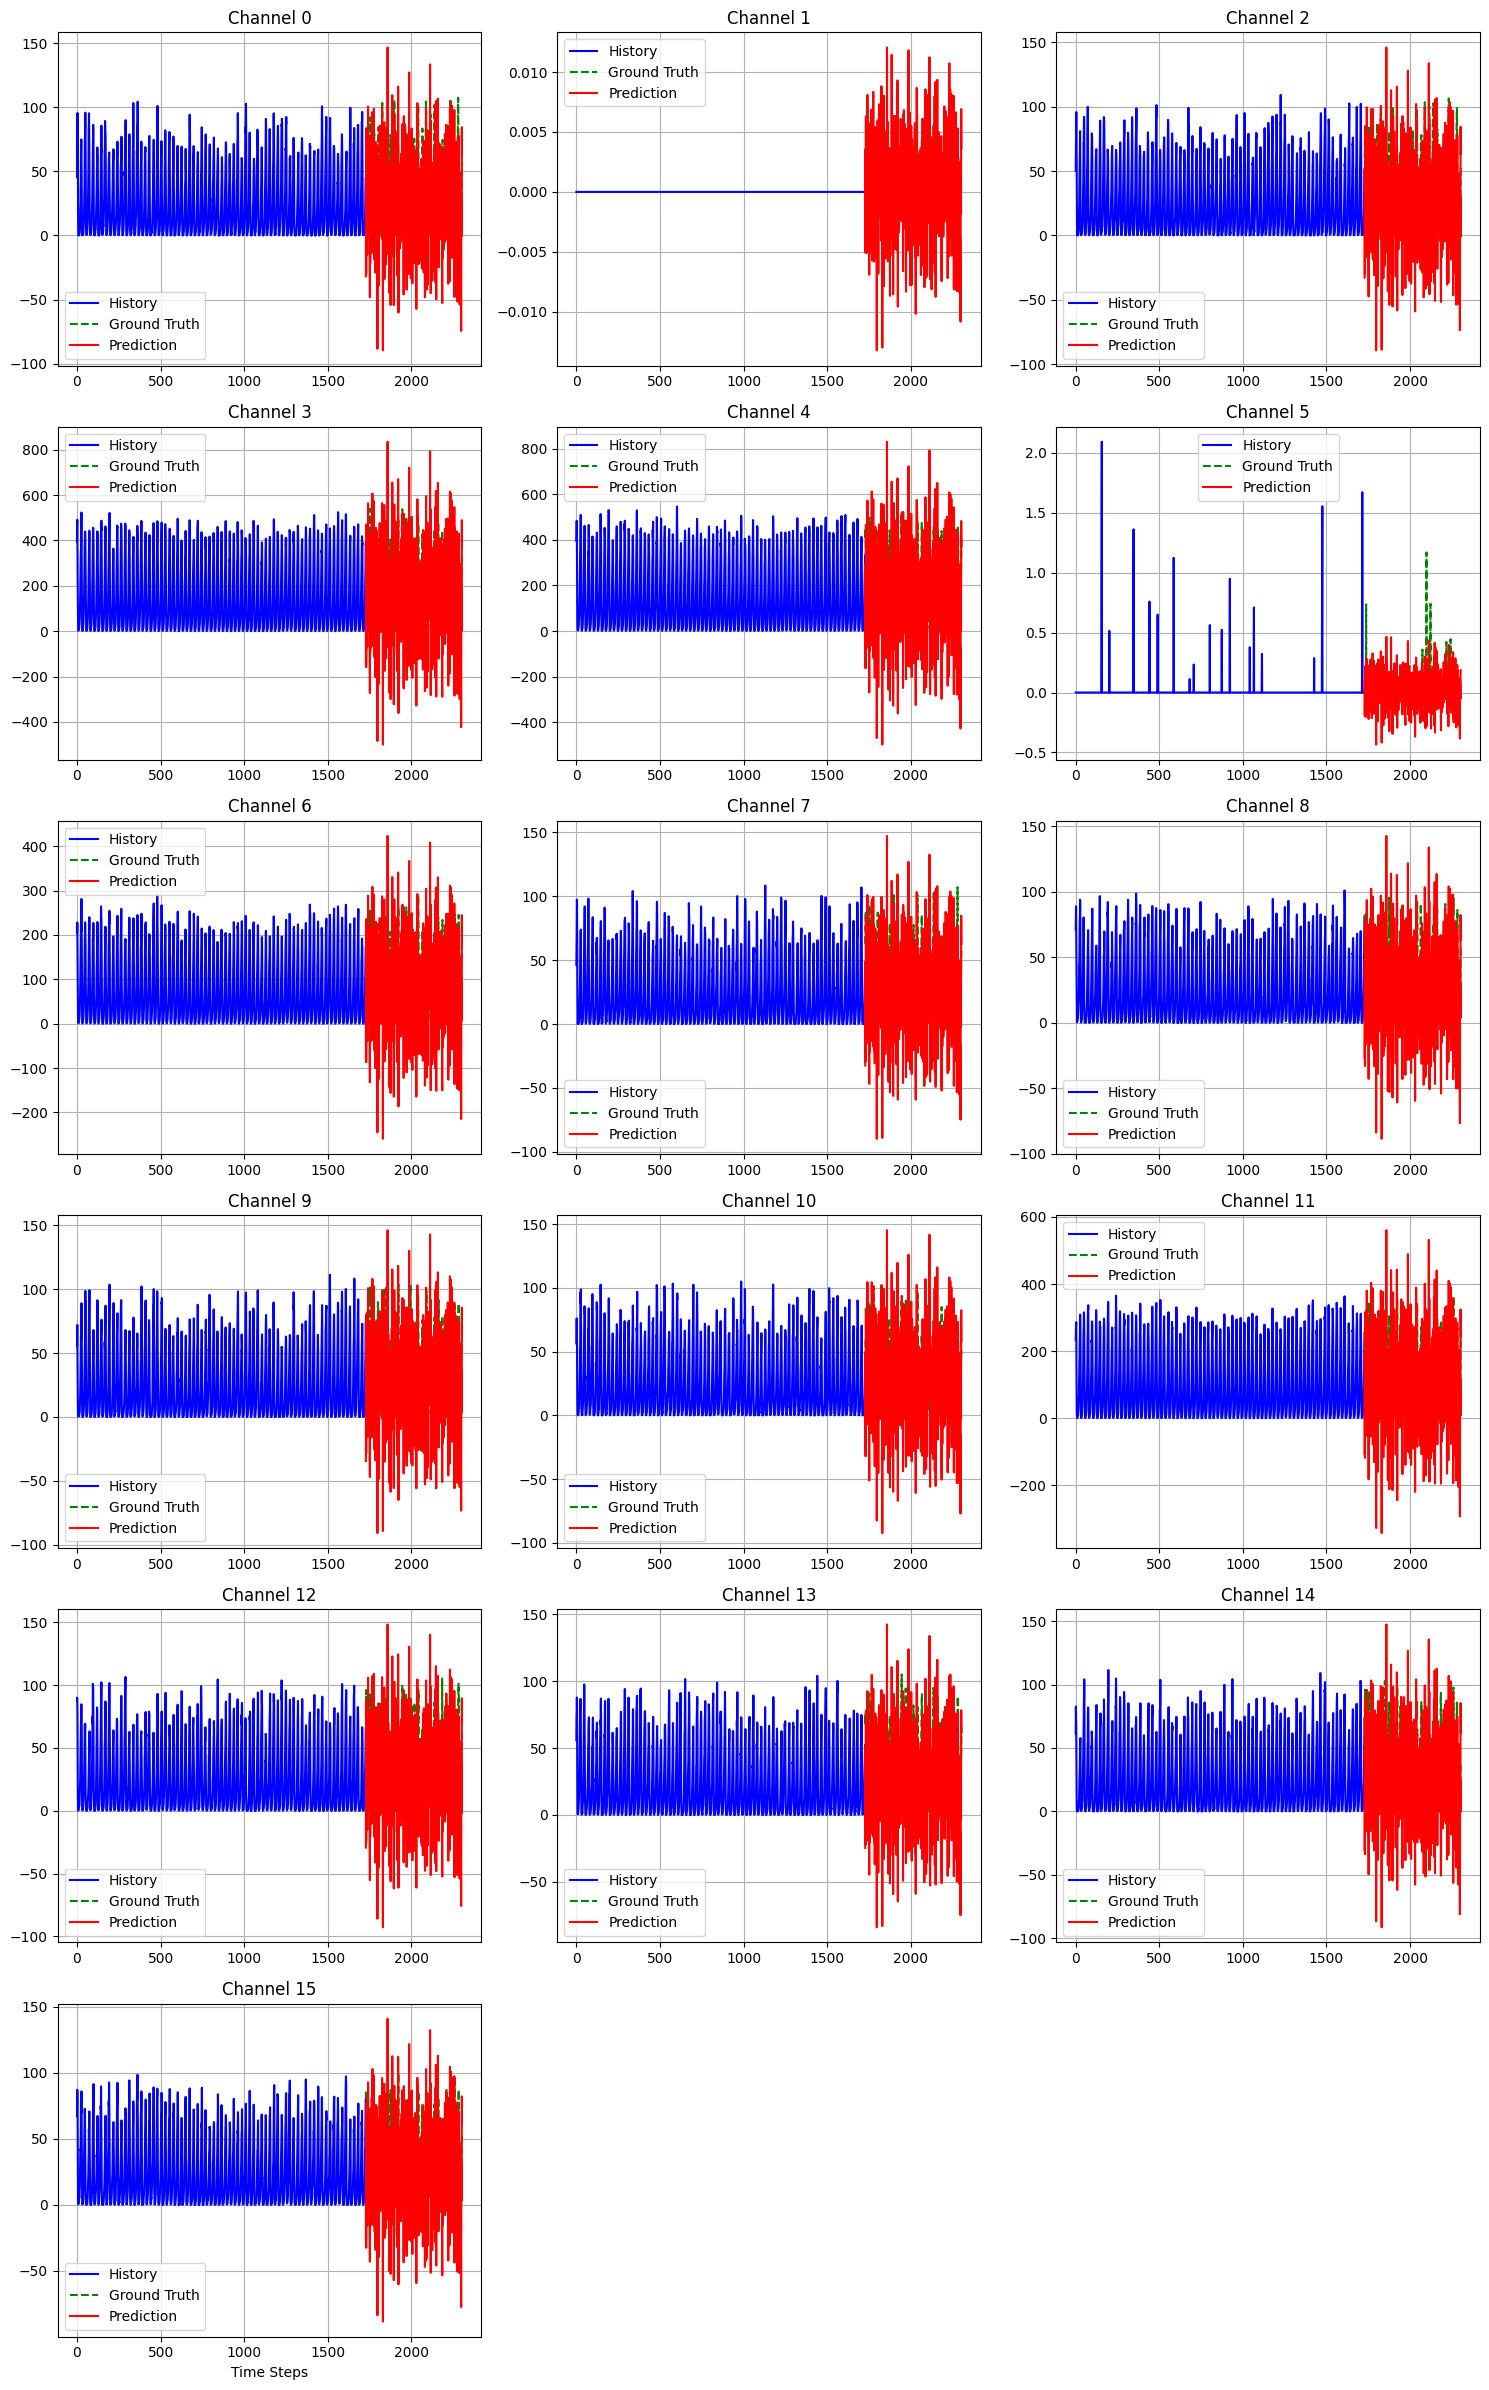

In [15]:
def plot_results(model, dataframe, seq_len, pred_len, sample_idx=0):
    """
    Plots the Input History, Ground Truth Future, and Model Prediction for a specific sample.
    """
    dataset = TimeSeriesDataset(dataframe, seq_len, pred_len)
    print(dataset[0][0].shape)
    print(dataset[0][1].shape)
    print(dataset[0][2].shape)
    # Get a single sample
    input_x, input_x_mark, true_y = dataset[sample_idx]


    # Add batch dimension for the model
    input_x_batch = input_x.unsqueeze(0)        # [1, seq_len, channels]
    input_x_mark_batch = input_x_mark.unsqueeze(0) # [1, seq_len, 4]

    print(input_x_batch.shape)
    print(input_x_mark_batch.shape)
    print(true_y.shape)


    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        input_x_batch = input_x_batch.to(device)
        input_x_mark_batch = input_x_mark_batch.to(device)
        pred_y = model(input_x_batch, input_x_mark_batch)

    # Convert to numpy for plotting
    input_x = input_x.numpy()
    true_y = true_y.numpy()
    pred_y = pred_y.cpu().numpy().squeeze(0) # Remove batch dim
    print(input_x.shape)
    print(true_y.shape)
    print(pred_y.shape)


    # Plotting
    # --- Setup for Grid Layout ---
    num_cols = 3
    num_channels = input_x.shape[1]
    # Calculate rows needed (ceiling division)
    num_rows = (num_channels + num_cols - 1) // num_cols

    # Create the subplots
    # Note: Increased width (15) to accommodate 3 columns
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows), sharex=False)

    # Flatten the axes array (makes it 1D so we can iterate over it easily)
    # If num_channels is small, axes might not be an array, so we ensure it is iterable
    if num_channels == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    # Time axis for plotting
    x_history = np.arange(seq_len)
    x_future = np.arange(seq_len, seq_len + pred_len)


    for i in range(num_channels):
        ax = axes_flat[i]

        # Plot History
        ax.plot(x_history, input_x[:, i], label='History', color='blue')

        # Plot Ground Truth
        ax.plot(x_future, true_y[:, i], label='Ground Truth', color='green', linestyle='dashed')

        # Plot Prediction
        ax.plot(x_future, pred_y[:, i], label='Prediction', color='red')

        ax.set_title(f"Channel {i}")
        ax.legend()
        ax.grid(True)
    # --- Clean up empty subplots ---
    # If num_channels isn't a perfect multiple of 3, hide the empty axes at the end
    for i in range(num_channels, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    plt.xlabel("Time Steps")
    plt.tight_layout()
    #plt.show()


MODEL = PatchTST(
    num_input_channels=CHANNELS,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    n_heads=4,
    n_layers=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
state_dict = torch.load(SAVE_PATH, map_location=device)
print(f"State dict loaded from {SAVE_PATH}")
MODEL.load_state_dict(state_dict)
MODEL.to(device)
MODEL.eval()

plot_results(MODEL, TSS, SEQ_LEN, PRED_LEN, sample_idx=40)

Starting evaluation on cuda...

--- Evaluation Results ---
Global MSE:  13786.8125
Global RMSE: 117.4173
Global MAE:  66.9442
Global MAPE: 7588917.97%


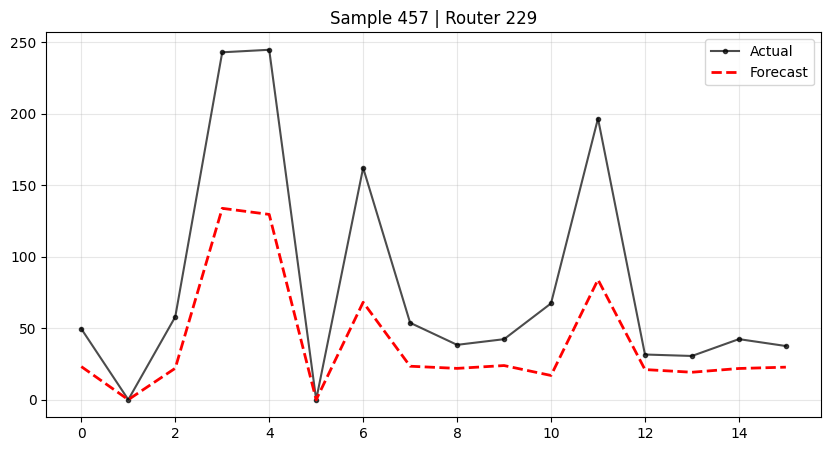

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_on(model, dataloader, criterion, device, plot_sample=True):
    """
    Evaluates the PatchTST model on the specified device (CPU or CUDA).
    
    Args:
        model: The trained PatchTST model.
        dataloader: Test/Validation DataLoader.
        criterion: Loss function (e.g., MSELoss).
        device: torch.device object (e.g., 'cuda' or 'cpu').
        plot_sample: Whether to plot a random forecast result.
        
    Returns:
        metrics: Dictionary with MSE, MAE, and Loss.
        preds: Numpy array of predictions (N, M, T).
        actuals: Numpy array of ground truth (N, M, T).
    """
    # 1. Move model to the selected device
    model.to(device)
    model.eval() 
    
    all_preds = []
    all_actuals = []
    total_loss = 0.0
    
    print(f"Starting evaluation on {device}...")
    
    # 2. Evaluation Loop (No Gradients)
    with torch.no_grad():
        for i, (batch_x, batch_x_time, batch_y) in enumerate(dataloader):
            # Move batch data to the specified device
            batch_x = batch_x.to(device)
            batch_x_time = batch_x_time.to(device)
            batch_y = batch_y.to(device)
            
            # Forward Pass
            preds = model(batch_x, batch_x_time)
            
            # Calculate Loss
            loss = criterion(preds, batch_y)
            total_loss += loss.item()
            
            # Store results
            # CRITICAL: We must detach and move to CPU before converting to numpy
            all_preds.append(preds.detach().cpu().numpy())
            all_actuals.append(batch_y.detach().cpu().numpy())

    # 3. Aggregate Results
    # Concatenate all batches into single arrays
    preds_np = np.concatenate(all_preds, axis=0)
    actuals_np = np.concatenate(all_actuals, axis=0)
    
    # 4. Calculate Metrics (Real-World Scale)
    mse = mean_squared_error(actuals_np.flatten(), preds_np.flatten())
    mae = mean_absolute_error(actuals_np.flatten(), preds_np.flatten())
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'MSE': mse,
        'MAE': mae, 
        'Avg_Batch_Loss': avg_loss
    }
    
    print(f"\n--- Evaluation Results ---")
    print(f"Global MSE: {mse:.4f}")
    print(f"Global MAE: {mae:.4f}")
    print(f"Avg Loss:   {avg_loss:.4f}")
    
    # 5. Optional Visualization
    if plot_sample:
        _plot_forecast(preds_np, actuals_np)
        
    return metrics, preds_np, actuals_np

def evaluate_on(model, dataloader, criterion, device, plot_sample=True):
    """
    Evaluates the PatchTST model including MAE, MSE, RMSE, and MAPE.
    """
    # 1. Move model to the selected device
    model.to(device)
    model.eval() 
    
    all_preds = []
    all_actuals = []
    total_loss = 0.0
    
    print(f"Starting evaluation on {device}...")
    
    # 2. Evaluation Loop (No Gradients)
    with torch.no_grad():
        for i, (batch_x, batch_x_time, batch_y) in enumerate(dataloader):
            # Move batch data to the specified device
            batch_x = batch_x.to(device)
            batch_x_time = batch_x_time.to(device)
            batch_y = batch_y.to(device)
            
            # Forward Pass
            preds = model(batch_x, batch_x_time)
            
            # Calculate Loss (Validation Loss)
            loss = criterion(preds, batch_y)
            total_loss += loss.item()
            
            # Store results (Detach from graph & move to CPU)
            all_preds.append(preds.detach().cpu().numpy())
            all_actuals.append(batch_y.detach().cpu().numpy())

    # 3. Aggregate Results
    # Concatenate all batches -> Single Numpy Array
    preds_np = np.concatenate(all_preds, axis=0)
    actuals_np = np.concatenate(all_actuals, axis=0)
    
    # Flatten arrays for 1D metric calculation
    flat_preds = preds_np.flatten()
    flat_actuals = actuals_np.flatten()
    
    # 4. Calculate Metrics
    # MSE (Mean Squared Error)
    mse = mean_squared_error(flat_actuals, flat_preds)
    
    # RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mse)
    
    # MAE (Mean Absolute Error)
    mae = mean_absolute_error(flat_actuals, flat_preds)
    
    # MAPE (Mean Absolute Percentage Error)
    # We add a tiny epsilon (1e-5) to denominator to avoid DivisionByZero if actual is 0
    epsilon = 1e-5
    mape = np.mean(np.abs((flat_actuals - flat_preds) / (flat_actuals + epsilon))) * 100
    
    avg_loss = total_loss / len(dataloader)
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_Percent': mape,
        'Avg_Batch_Loss': avg_loss
    }
    
    print(f"\n--- Evaluation Results ---")
    print(f"Global MSE:  {mse:.4f}")
    print(f"Global RMSE: {rmse:.4f}")
    print(f"Global MAE:  {mae:.4f}")
    print(f"Global MAPE: {mape:.2f}%")
    
    # 5. Optional Visualization
    if plot_sample:
        _plot_forecast(preds_np, actuals_np)
        
    return metrics, preds_np, actuals_np

def _plot_forecast(preds, actuals):
    """
    Helper function to plot a random sample from the numpy arrays.
    """
    # Pick random sample and random router
    sample_idx = np.random.randint(0, preds.shape[0])
    router_idx = np.random.randint(0, preds.shape[1])
    
    pred_series = preds[sample_idx, router_idx, :]
    actual_series = actuals[sample_idx, router_idx, :]
    
    plt.figure(figsize=(10, 5))
    plt.plot(actual_series, label='Actual', marker='.', color='black', alpha=0.7)
    plt.plot(pred_series, label='Forecast', linestyle='--', color='red', linewidth=2)
    plt.title(f"Sample {sample_idx} | Router {router_idx}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
   
criterion = torch.nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DS = TimeSeriesDataset(TSS, seq_len=SEQ_LEN, pred_len=PRED_LEN)
DATA_DL = DataLoader(DATA_DS, batch_size=BATCH_SIZE, shuffle=False)

metrics, preds, actuals = evaluate_on(
    model=MODEL, 
    dataloader=DATA_DL, 
    criterion=criterion,
    device=device,  
    plot_sample=True
)

In [19]:
## PREDICTION
def predict_future_dataframe(model, dataframe, seq_len, pred_len, freq='1h', device='cpu'):

    model.to(device)
    model.eval()

    dataset = TimeSeriesDataset(dataframe, seq_len=seq_len, pred_len=pred_len)
    
    last_idx = len(dataset) - 1
    batch_x, batch_x_mark, batch_y = dataset[last_idx]

    batch_x = batch_x.unsqueeze(0).to(device)         # [B, L, C]
    batch_x_mark = batch_x_mark.unsqueeze(0).to(device) # [B, L, 4]
    #batch_y = batch_y.to(device)         # [B, P, C]




    with torch.no_grad():
        preds = model(batch_x, batch_x_mark)

    preds = preds.cpu().numpy().squeeze()


    last_date = dataframe.index[-1]
    #freq = pd.infer_freq(dataframe.index)

    #if freq == 'D':
    #freq = '24h'

    offset = pd.to_timedelta(freq)

    future_dates = pd.date_range(start=last_date + offset, periods=pred_len, freq=freq)
    

    
    return  pd.DataFrame(preds, index=future_dates, columns=dataframe.columns)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#predict_future_dataframe(MODEL, TSS, SEQ_LEN, PRED_LEN,device=device)

TSS_PRED = TSS.copy()
OFFSET_PRED = TSS_PRED.index[-1]

PREDICTION_RANGE = 6
for _ in range(PREDICTION_RANGE):
    print("Predicting...")
    TSS_PRED = pd.concat([TSS_PRED, predict_future_dataframe(MODEL, TSS_PRED, SEQ_LEN, PRED_LEN,device=device)], axis=0)


Predicting...
Predicting...
Predicting...
Predicting...
Predicting...
Predicting...


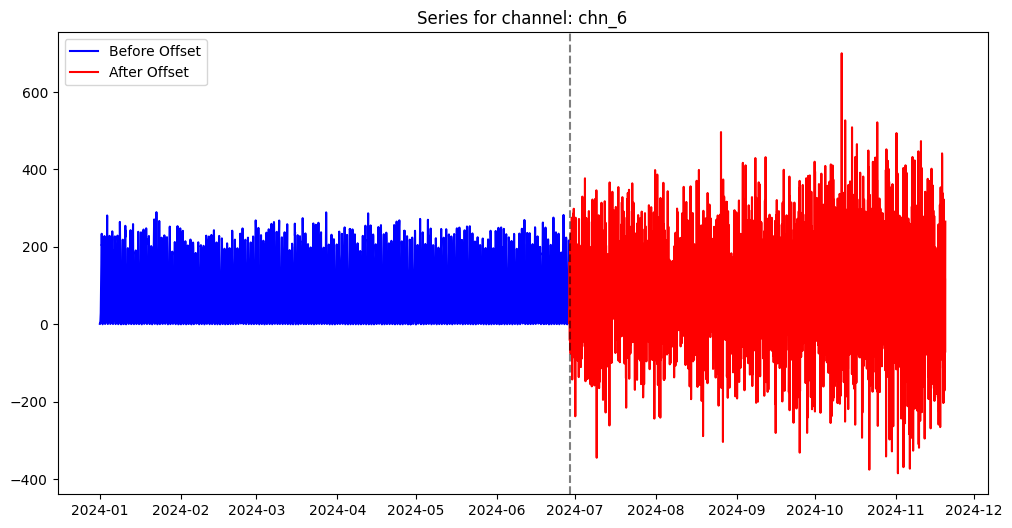

In [20]:
_rand_chan = TSS_PRED.T.sample(1).index[0]
_tss_plot = TSS_PRED[[_rand_chan]]


plt.figure(figsize=(12, 6))
plt.plot(_tss_plot.loc[:OFFSET_PRED, _rand_chan], color='blue', label='Before Offset')
plt.plot(_tss_plot.loc[OFFSET_PRED:, _rand_chan], color='red', label='After Offset')
plt.axvline(OFFSET_PRED, color='black', linestyle='--', alpha=0.5)
plt.title(f"Series for channel: {_rand_chan}")
plt.legend()
plt.show()
